In [2]:
# Libraries import karein
import cv2
import numpy as np
import matplotlib.pyplot as plt

# VS Code mein images show karne ke liye
%matplotlib inline

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [4]:
# Image load karein
image_path = 'dip 1.png'  # Apni image ka naam

# Image read karein
img = cv2.imread(image_path)

# Check karein image mili ya nahi
if img is None:
    print("❌ ERROR: Image not found!")
    print("Please make sure 'dip 1.png' is in the same folder")
else:
    # OpenCV BGR format mein read karta hai, RGB mein convert karein
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Image display karein
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title('Original Image', fontsize=14)
    plt.axis('off')
    plt.show()
    
    print(f"✅ Image loaded! Size: {img_rgb.shape}")

NameError: name 'cv2' is not defined

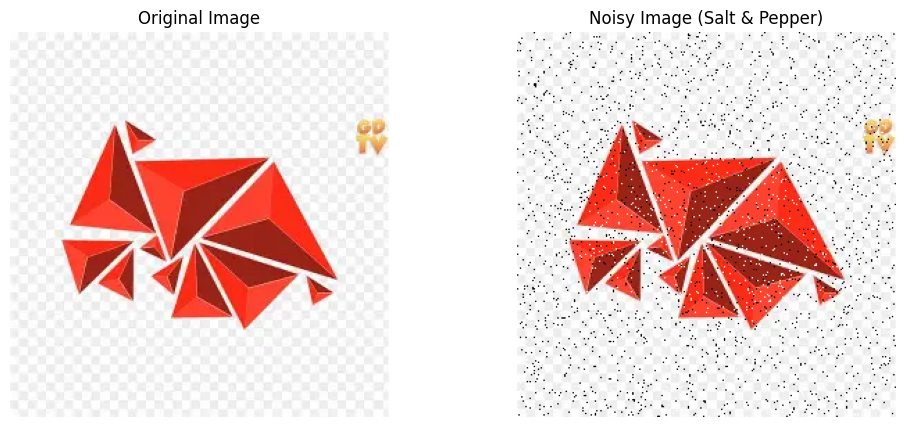

In [58]:
# Salt & Pepper noise add karne ka function
def add_noise(image):
    """Image mein salt & pepper noise add karein"""
    noisy = image.copy()
    h, w, c = image.shape
    
    # 5% pixels par noise add karein
    noise_amount = 0.05
    
    # Salt noise (white pixels) - 2.5% pixels
    salt_mask = np.random.random((h, w)) < noise_amount/2
    noisy[salt_mask] = 255
    
    # Pepper noise (black pixels) - 2.5% pixels
    pepper_mask = np.random.random((h, w)) < noise_amount/2
    noisy[pepper_mask] = 0
    
    return noisy

# Noise add karein
noisy_img = add_noise(img_rgb)

# Display karein
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_img)
plt.title('Noisy Image (Salt & Pepper)')
plt.axis('off')

plt.show()

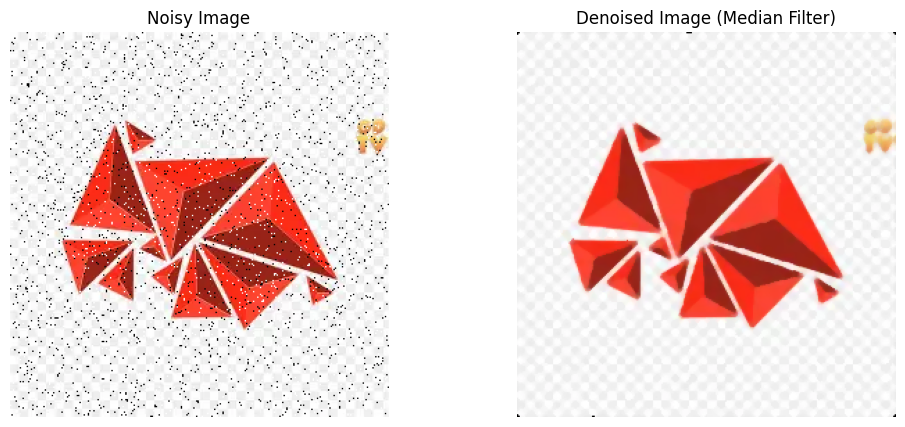

✅ Noise removed successfully!


In [59]:
# Median filter se noise remove karein
# Median filter salt-pepper noise ke liye best hai

# Pehle RGB channels alag karein
r_channel = noisy_img[:, :, 0]
g_channel = noisy_img[:, :, 1]
b_channel = noisy_img[:, :, 2]

# Har channel par median filter apply karein
from scipy.signal import medfilt2d

r_denoised = medfilt2d(r_channel, kernel_size=5)
g_denoised = medfilt2d(g_channel, kernel_size=5)
b_denoised = medfilt2d(b_channel, kernel_size=5)

# Dobara RGB image banayein
denoised_img = np.stack([r_denoised, g_denoised, b_denoised], axis=2)
denoised_img = denoised_img.astype(np.uint8)

# Display karein
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy_img)
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(denoised_img)
plt.title('Denoised Image (Median Filter)')
plt.axis('off')

plt.show()

print("✅ Noise removed successfully!")

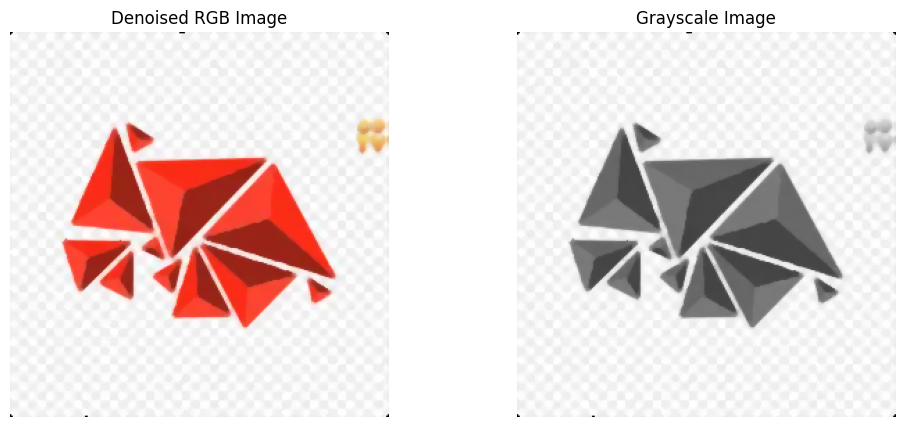

✅ Grayscale image shape: (278, 273)


In [60]:
# RGB se Grayscale mein convert karein
gray_img = cv2.cvtColor(denoised_img, cv2.COLOR_RGB2GRAY)

# Display karein
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(denoised_img)
plt.title('Denoised RGB Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.show()

print(f"✅ Grayscale image shape: {gray_img.shape}")

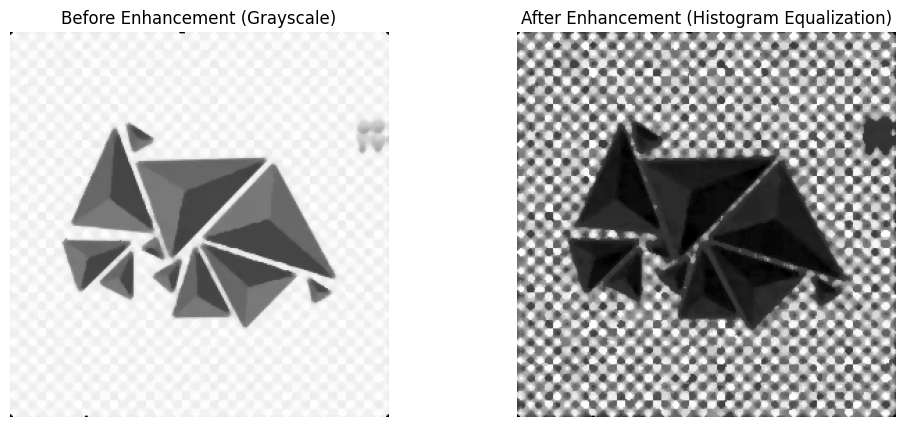

✅ Image enhanced successfully!


In [68]:
# Histogram Equalization - contrast improve karein
# Simple method: pixels ko spread karein taake image bright ho

# Image ko normalize karein (0 to 255 range mein)
enhanced_img = cv2.equalizeHist(gray_img)

# Display karein
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Before Enhancement (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img, cmap='gray')
plt.title('After Enhancement (Histogram Equalization)')
plt.axis('off')

plt.show()

print("✅ Image enhanced successfully!")

📊 Total contours found (before filtering): 605
✅ Objects detected (after filtering): 10


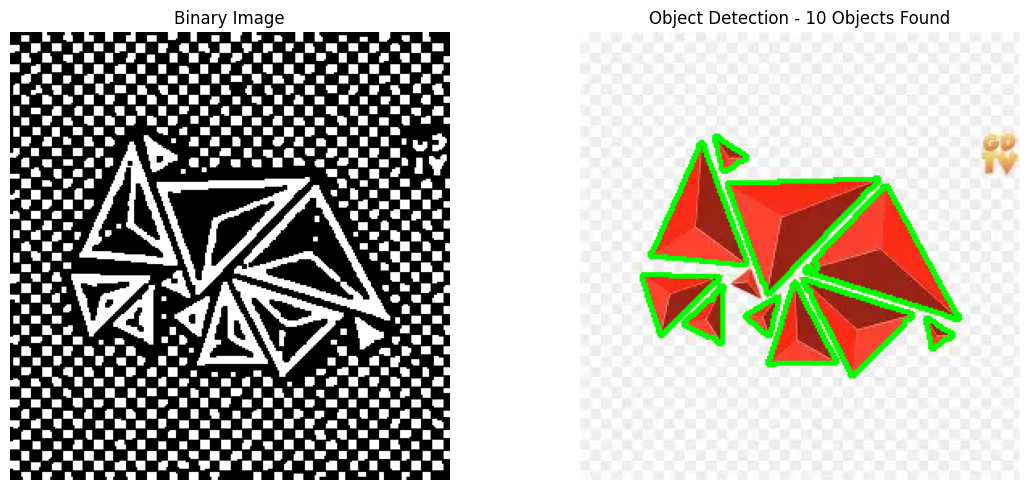


📊 OBJECT DETECTION SUMMARY
✅ Total objects detected: 10


In [74]:
# ============================================
# OBJECT DETECTION - EXTRA GREEN MARKS REMOVE
# Sirf real objects detect honge, extra green marks nahi
# ============================================

# Step 1: Original image ko grayscale mein convert karein
original_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Step 2: Image ko blur karein (noise kam karne ke liye)
blurred = cv2.GaussianBlur(original_gray, (5, 5), 0)

# Step 3: Binary image banayein (Adaptive Threshold)
binary_img = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11,
    2
)

# Step 4: Morphological operations
kernel = np.ones((3, 3), np.uint8)

# Opening = Erosion + Dilation (noise remove)
binary_img = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel, iterations=1)

# Closing = Dilation + Erosion (holes fill)
binary_img = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=1)

# Step 5: Contours find karein
contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"📊 Total contours found (before filtering): {len(contours)}")

# Step 6: ✅ SIRF BADE OBJECTS FILTER KAREIN (Extra green marks hatane ke liye)
min_area = 130  # 👈 300 se chhote objects ignore honge
objects = []

for contour in contours:
    area = cv2.contourArea(contour)
    if area > min_area:
        objects.append(contour)

print(f"✅ Objects detected (after filtering): {len(objects)}")

# Step 7: Result image banayein
result_img = img_rgb.copy()
cv2.drawContours(result_img, objects, -1, (0, 255, 0), 2)

# Step 8: Display - Binary + Result
plt.figure(figsize=(12, 5))

# Binary Image
plt.subplot(1, 2, 1)
plt.imshow(binary_img, cmap='gray')
plt.title('Binary Image', fontsize=12)
plt.axis('off')

# Result Image
plt.subplot(1, 2, 2)
plt.imshow(result_img)
plt.title(f'Object Detection - {len(objects)} Objects Found', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*50)
print("📊 OBJECT DETECTION SUMMARY")
print("="*50)
print(f"✅ Total objects detected: {len(objects)}")
print("="*50)

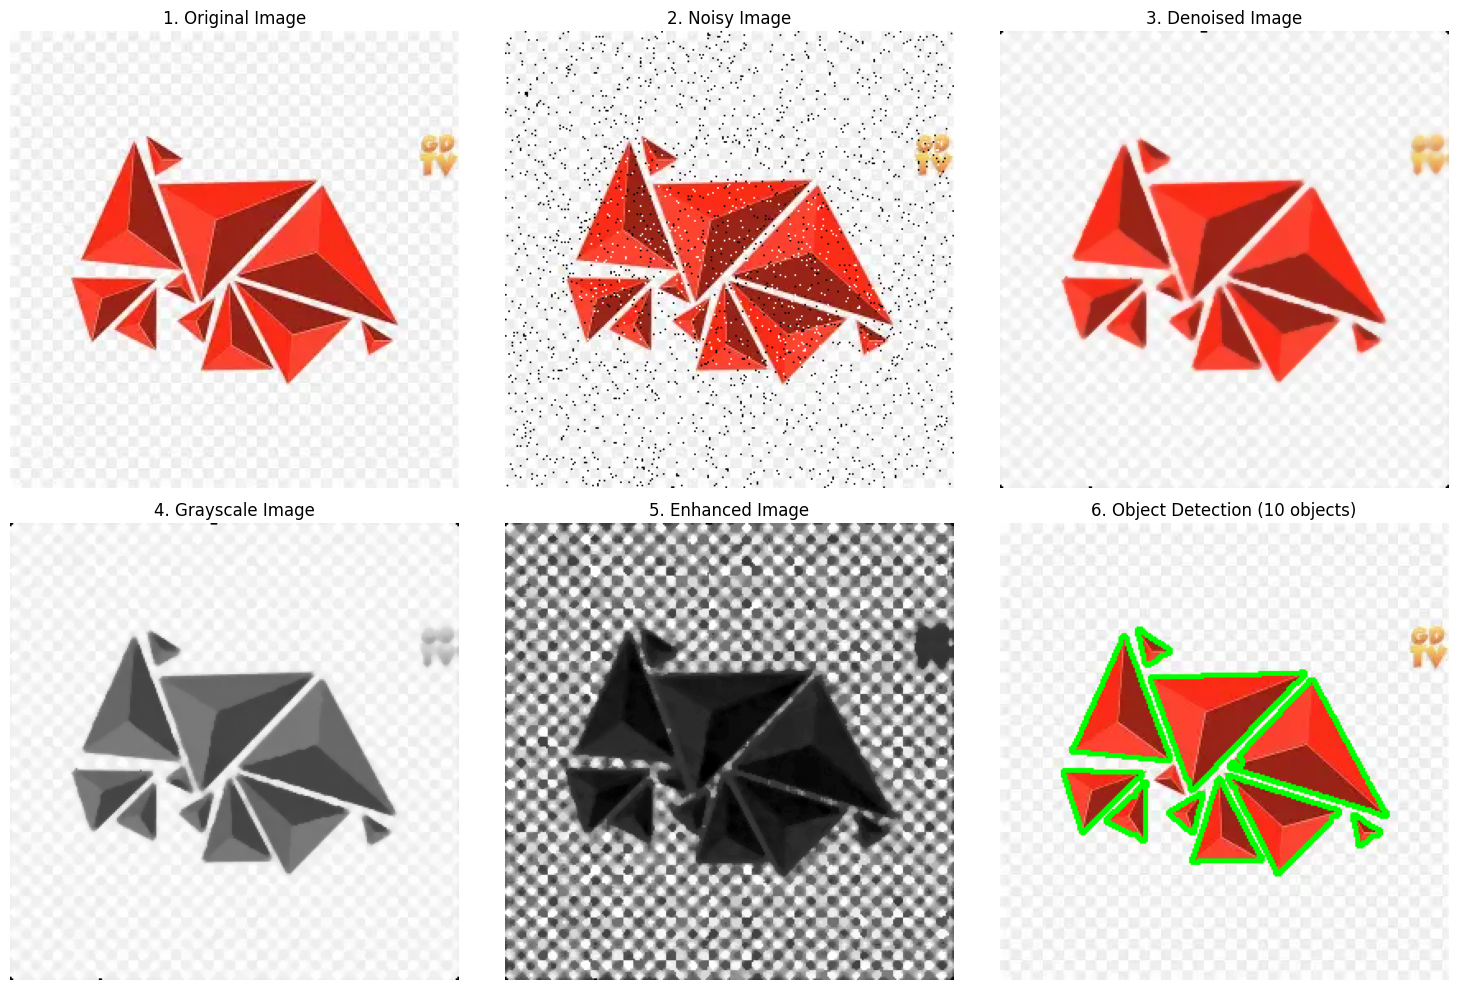

In [70]:
# Sab results ek saath display karein
plt.figure(figsize=(15, 10))

# 1. Original
plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title('1. Original Image')
plt.axis('off')

# 2. Noisy
plt.subplot(2, 3, 2)
plt.imshow(noisy_img)
plt.title('2. Noisy Image')
plt.axis('off')

# 3. Denoised
plt.subplot(2, 3, 3)
plt.imshow(denoised_img)
plt.title('3. Denoised Image')
plt.axis('off')

# 4. Grayscale
plt.subplot(2, 3, 4)
plt.imshow(gray_img, cmap='gray')
plt.title('4. Grayscale Image')
plt.axis('off')

# 5. Enhanced
plt.subplot(2, 3, 5)
plt.imshow(enhanced_img, cmap='gray')
plt.title('5. Enhanced Image')
plt.axis('off')

# 6. Object Detection
plt.subplot(2, 3, 6)
plt.imshow(result_img)
plt.title(f'6. Object Detection ({len(objects)} objects)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Output folder banayein
import os
output_folder = 'output_images'
os.makedirs(output_folder, exist_ok=True)

# Sab images save karein
cv2.imwrite(f'{output_folder}/1_original.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(f'{output_folder}/2_noisy.jpg', cv2.cvtColor(noisy_img, cv2.COLOR_RGB2BGR))
cv2.imwrite(f'{output_folder}/3_denoised.jpg', cv2.cvtColor(denoised_img, cv2.COLOR_RGB2BGR))
cv2.imwrite(f'{output_folder}/4_grayscale.jpg', gray_img)
cv2.imwrite(f'{output_folder}/5_enhanced.jpg', enhanced_img)
cv2.imwrite(f'{output_folder}/6_binary.jpg', binary_img)
cv2.imwrite(f'{output_folder}/7_object_detection.jpg', cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR))


print("✅ All images saved successfully!")
print(f"📁 Folder: {output_folder}/")
print("\nSaved files:")
for file in os.listdir(output_folder):
    print(f"  - {file}")

✅ All images saved successfully!
📁 Folder: output_images/

Saved files:
  - 1_original.jpg
  - 2_noisy.jpg
  - 3_denoised.jpg
  - 4_grayscale.jpg
  - 5_enhanced.jpg
  - 6_binary.jpg
  - 7_object_detection.jpg
  - 8_shape_detection.jpg
